In [7]:
#(Q1)
#a
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns 

In [8]:
#b
df = pd.read_csv("bioinformatics_visualization_practice_dataset.csv")
df

,Patient_ID,Age,Gender,Disease_Status,Gene_A_Expression,Gene_B_Expression,Gene_C_Expression,Blood_Pressure,Glucose,Mutation_A,Mutation_B,Mutation_C
0,P1001,60,Male,At Risk,5.55,5.97,4.94,148,115.0,Yes,Yes,Yes
1,P1002,50,Female,Healthy,4.43,5.54,3.40,137,102.0,No,Yes,No
2,P1003,36,Male,Disease,8.65,8.22,4.44,147,102.0,No,Yes,No
3,P1004,64,Female,Healthy,3.74,5.73,4.31,141,93.0,Yes,Yes,No
4,P1005,29,Male,Disease,8.17,7.84,3.23,110,111.0,Yes,No,No
5,P1006,42,Female,Healthy,5.42,2.76,3.44,128,89.0,Yes,Yes,No
6,P1007,60,Female,At Risk,4.35,5.09,3.87,130,113.0,Yes,No,No
7,P1008,40,Male,Healthy,4.89,8.25,5.17,135,NaN,No,No,No
8,P1009,44,Female,At Risk,7.16,6.57,5.55,130,90.0,No,Yes,No
9,P1010,32,Female,Healthy,6.11,3.32,5.13,122,96.0,No,No,No


In [9]:
df.head()

,Patient_ID,Age,Gender,Disease_Status,Gene_A_Expression,Gene_B_Expression,Gene_C_Expression,Blood_Pressure,Glucose,Mutation_A,Mutation_B,Mutation_C
0,P1001,60,Male,At Risk,5.55,5.97,4.94,148,115.0,Yes,Yes,Yes
1,P1002,50,Female,Healthy,4.43,5.54,3.40,137,102.0,No,Yes,No
2,P1003,36,Male,Disease,8.65,8.22,4.44,147,102.0,No,Yes,No
3,P1004,64,Female,Healthy,3.74,5.73,4.31,141,93.0,Yes,Yes,No
4,P1005,29,Male,Disease,8.17,7.84,3.23,110,111.0,Yes,No,No


In [10]:
df.shape

(40, 12)

In [11]:
tung = df.shape
yo = df.columns

for i in range(tung[1]) : print(yo[i])

Patient_ID
Age
Gender
Disease_Status
Gene_A_Expression
Gene_B_Expression
Gene_C_Expression
Blood_Pressure
Glucose
Mutation_A
Mutation_B
Mutation_C


In [12]:
df.dtypes

Patient_ID            object
Age                    int64
Gender                object
Disease_Status        object
Gene_A_Expression    float64
Gene_B_Expression    float64
Gene_C_Expression    float64
Blood_Pressure         int64
Glucose              float64
Mutation_A            object
Mutation_B            object
Mutation_C            object
dtype: object

In [13]:
#e
df.isnull().sum()

Patient_ID           0
Age                  0
Gender               0
Disease_Status       0
Gene_A_Expression    0
Gene_B_Expression    1
Gene_C_Expression    0
Blood_Pressure       0
Glucose              1
Mutation_A           0
Mutation_B           0
Mutation_C           0
dtype: int64

In [14]:
# df.isnull().sum()
df.columns[df.isnull().any()]

Index(['Gene_B_Expression', 'Glucose'], dtype='object')

In [15]:
#Q2
count = df["Disease_Status"].value_counts()
print(count)

Disease_Status
Disease    16
At Risk    12
Healthy    12
Name: count, dtype: int64


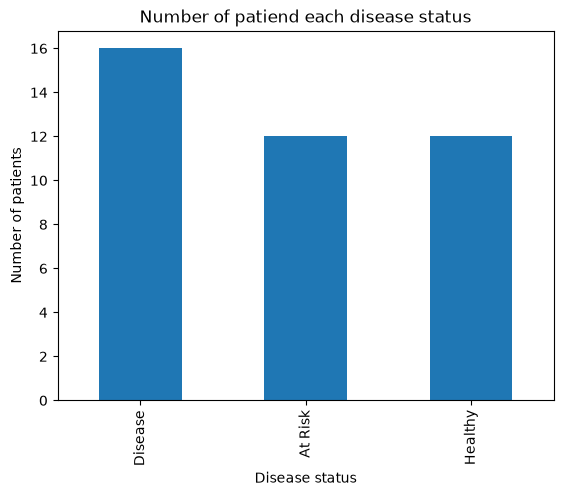

In [16]:
count.plot(kind = "bar")
plt.title("Number of patiend each disease status")
plt.xlabel("Disease status")
plt.ylabel("Number of patients")
plt.show()


In [17]:
print("highest number of patients: ", count.max())

highest number of patients:  16


In [18]:
#Q3
mean_gene = df.groupby("Disease_Status")[["Gene_A_Expression", "Gene_B_Expression", "Gene_C_Expression"]].mean()

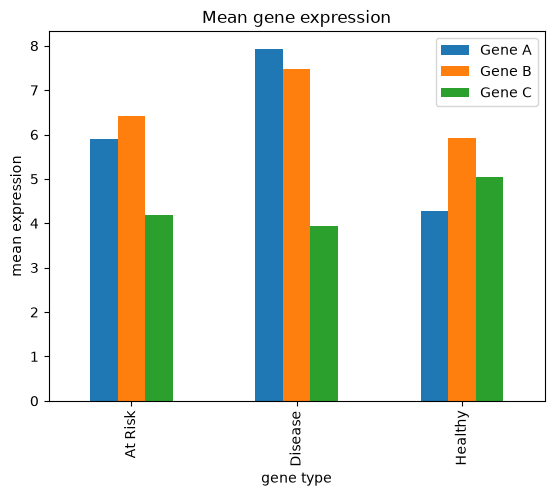

In [19]:
mean_gene.plot(kind = "bar")
plt.title("Mean gene expression")
plt.xlabel("gene type")
plt.ylabel("mean expression")
plt.legend(["Gene A", "Gene B", "Gene C"])
plt.show()

In [20]:
mean_gene.max()

Gene_A_Expression    7.930000
Gene_B_Expression    7.478000
Gene_C_Expression    5.045833
dtype: float64

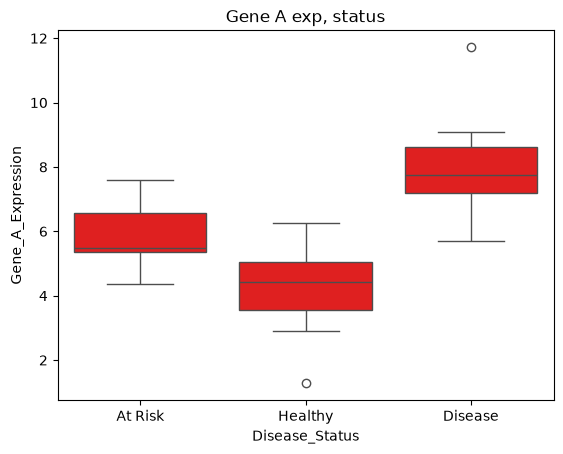

In [30]:
#Q4
sns.boxplot(
    data = df,
    x = "Disease_Status",
    y = "Gene_A_Expression",
    color = 'red'
)

plt.title("Gene A exp, status")
plt.xlabel("Disease_Status")
plt.ylabel("Gene_A_Expression")
plt.show()

In [22]:
#b
median = df.groupby("Disease_Status")["Gene_A_Expression"].median()
print(median)

Disease_Status
At Risk    5.495
Disease    7.755
Healthy    4.415
Name: Gene_A_Expression, dtype: float64


In [23]:
print(median.idxmax())

Disease


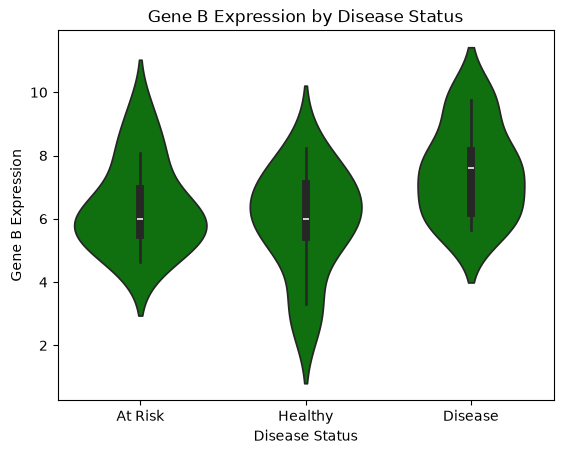

In [24]:
# Q5 – Violin Plot

sns.violinplot(
    data=df,
    x="Disease_Status",
    y="Gene_B_Expression",
    
    color = "green"
)

plt.title("Gene B Expression by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Gene B Expression")
plt.show()

In [25]:
mean_b = df.groupby("Disease_Status")[
    "Gene_B_Expression"
].mean()

print("Mean Gene B:")
print(mean_b)

print("Higher Gene B group:", mean_b.idxmax())

print("Violin width shows the density of data.")


Mean Gene B:
Disease_Status
At Risk    6.415833
Disease    7.478000
Healthy    5.912500
Name: Gene_B_Expression, dtype: float64
Higher Gene B group: Disease
Violin width shows the density of data.


In [26]:
# Q6 – Heatmap

columns = [
    "Age",
    "Gene_A_Expression",
    "Gene_B_Expression",
    "Gene_C_Expression",
    "Blood_Pressure",
    "Glucose"
]

corr = df[columns].corr()

print(corr)

                        Age  Gene_A_Expression  Gene_B_Expression  \
Age                1.000000          -0.025905           0.202976   
Gene_A_Expression -0.025905           1.000000           0.227354   
Gene_B_Expression  0.202976           0.227354           1.000000   
Gene_C_Expression -0.128743          -0.341759          -0.235934   
Blood_Pressure     0.827266          -0.066273           0.171765   
Glucose            0.550290           0.294534           0.241752   

                   Gene_C_Expression  Blood_Pressure   Glucose  
Age                        -0.128743        0.827266  0.550290  
Gene_A_Expression          -0.341759       -0.066273  0.294534  
Gene_B_Expression          -0.235934        0.171765  0.241752  
Gene_C_Expression           1.000000       -0.036898 -0.290527  
Blood_Pressure             -0.036898        1.000000  0.470189  
Glucose                    -0.290527        0.470189  1.000000  


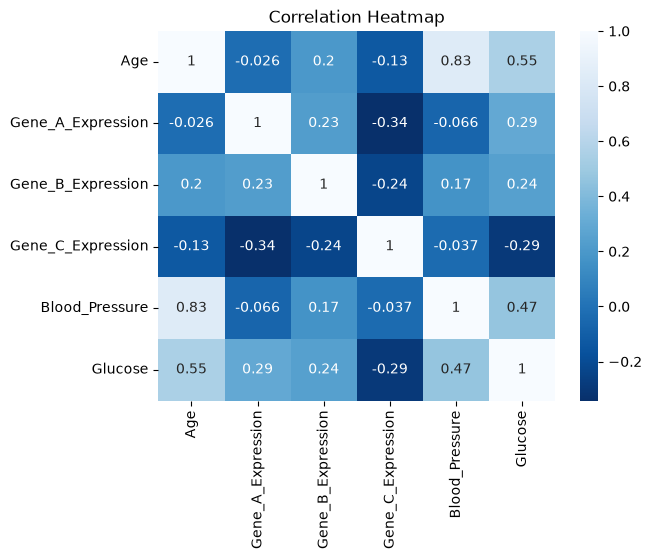

In [27]:
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues_r" #vlag, plasma, Blues_r, spectral, coolwarm
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
# c) Find strongest positive correlation
corr2 = corr.copy()

for i in range(len(corr2)):
    corr2.iloc[i, i] = 0

print("Strongest positive correlation:")

print(corr2.stack().idxmax())
print(corr2.stack().max())

Strongest positive correlation:
('Age', 'Blood_Pressure')
0.8272658325720097
